In [3]:
import torch
import numpy as np
import yaml
import sys
from pathlib import Path
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from PIL import Image
from model import CMCDNet
from dataset import ChangeDetctionDataset

# Load config
config_path = project_root / "notebook" / "config.yaml"
config_candidates = [
    config_path,
    project_root / "config.yaml",
    Path.cwd() / "config.yaml",
]

config_path = next((p for p in config_candidates if p.exists()), config_candidates[0])

with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)
from transform import ValTransform
from utils.mask_utils import remap_labels
from torch.utils.data import DataLoader
from loss import LossFunction

In [6]:
hyperparameter = cfg["training"]
validation = cfg["data"]["val"]
test = cfg["data"]["test"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CMCDNet()

ckpt_path = "D:\Karan_Jayakumar_Galaxeye\checkpoint\model_checkpoint.pth"  # update to a compatible checkpoint if needed
checkpoint = torch.load(ckpt_path, map_location="cpu")
state_dict = checkpoint.get("model_state_dict", checkpoint)

# Strip common wrapper prefixes from saved checkpoints
for prefix in ("_orig_mod.", "module."):
    if any(k.startswith(prefix) for k in state_dict.keys()):
        state_dict = {k.replace(prefix, "", 1): v for k, v in state_dict.items()}
        break

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
if missing_keys or unexpected_keys:
    print(f"Missing keys: {len(missing_keys)} | Unexpected keys: {len(unexpected_keys)}")
    print("Tip: set ckpt_path to a checkpoint saved from the same model definition.")

<>:8: SyntaxWarning: invalid escape sequence '\K'
<>:8: SyntaxWarning: invalid escape sequence '\K'
C:\Users\Karan\AppData\Local\Temp\ipykernel_36700\2197266461.py:8: SyntaxWarning: invalid escape sequence '\K'
  ckpt_path = "D:\Karan_Jayakumar_Galaxeye\checkpoint\model_checkpoint.pth"  # update to a compatible checkpoint if needed
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [4]:
### Validation split

criterion = LossFunction()

val_dataset = ChangeDetctionDataset(
    pre_img_path=validation["pre_event"],
    post_img_path=validation["post_event"],
    target_img_path=validation["target"],
    patch_size=cfg["data"]["patch_size"],
    stride=cfg["data"]["stride"],
    index_path=None,
    build_metadata=False,
    transform=ValTransform(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=hyperparameter["batch_size"],
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
 )

threshold = cfg["training"].get("threshold", 0.40)

model = model.to(device)
model.eval()

val_loss_sum = 0.0
total_tp = 0
total_fp = 0
total_fn = 0

with torch.no_grad():
    for pre, post, target, _ in val_loader:
        pre = pre.to(device)
        post = post.to(device)
        target = target.to(device)

        logits = model(pre, post)
        loss = criterion(logits, target)
        val_loss_sum += loss.item()

        pred = (torch.sigmoid(logits) > threshold)
        target_mask = target.unsqueeze(1) if target.dim() == 3 else target
        target_mask = target_mask.bool()
        tp = (pred & target_mask).sum().item()
        fp = (pred & ~target_mask).sum().item()
        fn = (~pred & target_mask).sum().item()
        total_tp += tp
        total_fp += fp
        total_fn += fn

val_loss = val_loss_sum / max(1, len(val_loader))
precision = total_tp / (total_tp + total_fp + 1e-3)
recall = total_tp / (total_tp + total_fn + 1e-3)
f1 = (2 * precision * recall) / (precision + recall + 1e-3)
iou = total_tp / (total_tp + total_fp + total_fn + 1e-3)

print(f"val_loss: {val_loss:.4f}")
print(f"precision: {precision:.4f} | recall: {recall:.4f} | f1: {f1:.4f} | iou: {iou:.4f}")

val_loss: 0.2352
precision: 0.5474 | recall: 0.6885 | f1: 0.6094 | iou: 0.4388


In [8]:
### Test Split
criterion = LossFunction()

test_dataset = ChangeDetctionDataset(
    pre_img_path=str(project_root / test["pre_event"]),
    post_img_path=str(project_root / test["post_event"]),
    target_img_path=str(project_root / test["target"]),
    patch_size=cfg["data"]["patch_size"],
    stride=cfg["data"]["stride"],
    index_path=None,
    build_metadata=False,
    transform=ValTransform(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4,
 )

threshold = cfg["training"].get("threshold", 0.40)
# threshold = 0.20

# model = model.to(device)
# model.eval()

# test_loss_sum = 0.0
# total_tp = 0
# total_fp = 0
# total_fn = 0

# with torch.no_grad():
#     for pre, post, target, _ in test_loader:
#         pre = pre.to(device)
#         post = post.to(device)
#         target = target.to(device)

#         logits = model(pre, post)
#         loss = criterion(logits, target)
#         test_loss_sum += loss.item()

#         pred = (torch.sigmoid(logits) > threshold)
#         target_mask = target.unsqueeze(1) if target.dim() == 3 else target
#         target_mask = target_mask.bool()
#         tp = (pred & target_mask).sum().item()
#         fp = (pred & ~target_mask).sum().item()
#         fn = (~pred & target_mask).sum().item()
#         total_tp += tp
#         total_fp += fp
#         total_fn += fn

# test_loss = test_loss_sum / max(1, len(test_loader))
# precision = total_tp / (total_tp + total_fp + 1e-3)
# recall = total_tp / (total_tp + total_fn + 1e-3)
# f1 = (2 * precision * recall) / (precision + recall + 1e-3)
# iou = total_tp / (total_tp + total_fp + total_fn + 1e-3)

# print(f"test_loss: {test_loss:.4f}")
# print(f"precision: {precision:.4f} | recall: {recall:.4f} | f1: {f1:.4f} | iou: {iou:.4f}")

In [ ]:
# Manual selection
split = "val"          # "val" or "test"
patch_index = 124       # change this to inspect a different patch
manual_threshold = threshold

dataset = val_dataset if split == "val" else test_dataset
assert 0 <= patch_index < len(dataset), f"patch_index must be in [0, {len(dataset)-1}]"

pre, post, target, meta = dataset[patch_index]

# Build a batch for inference
pre_b = pre.unsqueeze(0).to(device)
post_b = post.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(pre_b, post_b)
    pred_mask = (torch.sigmoid(logits) > manual_threshold).squeeze().detach().cpu().numpy().astype(np.uint8)

# Convert tensors for plotting
pre_np = pre.detach().cpu().numpy()
post_np = post.detach().cpu().numpy()
target_np = target.detach().cpu().numpy()

if pre_np.ndim == 3:
    pre_vis = pre_np.mean(axis=0)
else:
    pre_vis = pre_np

if post_np.ndim == 3:
    post_vis = post_np.mean(axis=0)
else:
    post_vis = post_np

if target_np.ndim == 3:
    gt_mask = target_np.squeeze(0)
else:
    gt_mask = target_np
gt_mask = (gt_mask > 0).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(pre_vis, cmap="gray")
axes[0].set_title("Pre-event patch")
axes[1].imshow(post_vis, cmap="gray")
axes[1].set_title("Post-event patch")
axes[2].imshow(pred_mask, cmap="Reds", vmin=0, vmax=1)
axes[2].set_title(f"Predicted change (thr={manual_threshold:.2f})")
axes[3].imshow(gt_mask, cmap="Blues", vmin=0, vmax=1)
axes[3].set_title("Ground truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Selected patch metadata:", meta)
print(f"Pred changed pixels: {int(pred_mask.sum())} | GT changed pixels: {int(gt_mask.sum())}")

In [ ]:
import os
import rasterio

pre_image_parser = sorted(os.listdir(validation["pre_event"]))
post_image_parser = sorted(os.listdir(validation["post_event"]))
target_image_parser = sorted(os.listdir(validation["target"]))
print(len(pre_image_parser))



fig, ax = plt.subplots(1, 3, figsize=(10, 5))

# 2123 - best
pre_path = validation["pre_event"] + "/" + pre_image_parser[1]
post_path = validation["post_event"] + "/" + post_image_parser[1]
target_path = validation["target"] + "/" + target_image_parser[1]

print(pre_path)

with rasterio.open(pre_path) as pre_src:
    arr_1 = pre_src.read()
    print(arr_1.shape)
    if arr_1.shape[0] >= 3:
        pre_img = Image.fromarray(arr_1[:3].transpose(1, 2, 0))
        ax[0].imshow(pre_img)
    else:
        ax[0].imshow(arr_1[0], cmap="gray")
    ax[0].set_title("Pre-Event Image")
    ax[0].axis("off")

with rasterio.open(post_path) as post_src:
    arr_2 = post_src.read()
    print(arr_2.shape)
    if arr_2.shape[0] >= 3:
        post_img = Image.fromarray(arr_2[:3].transpose(1, 2, 0))
        ax[1].imshow(post_img)
        ax[1].set_title("Post-Event Image")
    else:
        ax[1].imshow(arr_2[0], cmap="gray")
        ax[1].set_title("Post-Event Image")
    ax[1].axis("off")

with rasterio.open(target_path) as target_src:
    arr_3 = target_src.read()
    print(arr_3.shape)
    print(np.unique(arr_3))
    target_img = remap_labels(arr_3.transpose(1, 2, 0))
    print(np.unique(target_img))
    if arr_3.shape[0] >= 3:
        target_img = Image.fromarray(arr_3[:3].transpose(1, 2, 0))
        ax[2].imshow(target_img)
    else:
        ax[2].imshow(arr_3[0], cmap="gray")
    ax[2].set_title("Target Image")
    ax[2].axis("off")
plt.tight_layout()
plt.show()


- scene_03_000001_building_damage.tif | precision: 0.9202 | recall: 0.5283 | f1: 0.6708 | iou: 0.5052
- scene_05_000009_building_damage.tif | precision: 0.3963 | recall: 0.7407 | f1: 0.5159 | iou: 0.3480
- scene_06_000013_building_damage.tif | precision: 0.8220 | recall: 0.4892 | f1: 0.6129 | iou: 0.4423
- scene_06_000041_building_damage.tif | precision: 0.9077 | recall: 0.6503 | f1: 0.7573 | iou: 0.6100
- scene_06_000063_building_damage.tif | precision: 0.9428 | recall: 0.7369 | f1: 0.8267 | iou: 0.7053
- scene_06_000065_building_damage.tif | precision: 0.9829 | recall: 0.7816 | f1: 0.8703 | iou: 0.7711
- scene_06_000070_building_damage.tif | precision: 0.9627 | recall: 0.4237 | f1: 0.5880 | iou: 0.4168
- scene_06_000084_building_damage.tif | precision: 0.9827 | recall: 0.4465 | f1: 0.6136 | iou: 0.4431
- scene_06_000089_building_damage.tif | precision: 0.9466 | recall: 0.7463 | f1: 0.8341 | iou: 0.7162
- scene_08_000106_building_damage.tif | precision: 0.5844 | recall: 0.5264 | f1: 0.5534 | iou: 0.3830
- scene_08_000108_building_damage.tif | precision: 0.8073 | recall: 0.3919 | f1: 0.5273 | iou: 0.3584
- scene_08_000110_building_damage.tif | precision: 0.8359 | recall: 0.3928 | f1: 0.5340 | iou: 0.3647
- scene_08_000111_building_damage.tif | precision: 0.6648 | recall: 0.4992 | f1: 0.5697 | iou: 0.3988
- scene_08_000113_building_damage.tif | precision: 0.8910 | recall: 0.3527 | f1: 0.5050 | iou: 0.3381

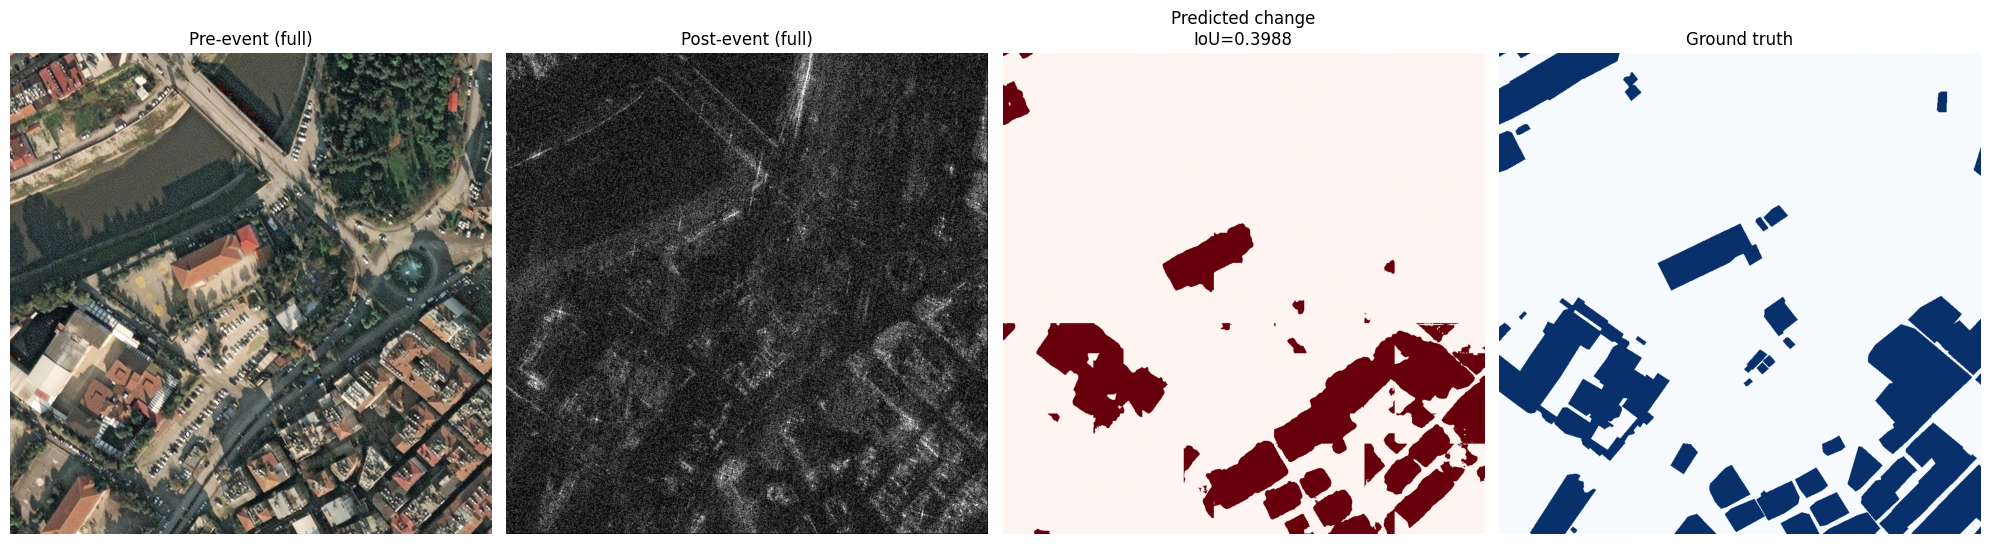

Image files: scene_08_000111_building_damage.tif scene_08_000111_building_damage.tif scene_08_000111_building_damage.tif
precision: 0.6648 | recall: 0.4992 | f1: 0.5697 | iou: 0.3988


In [39]:
import os
import rasterio

# Full-image evaluation (stitched from patches)
split = "val"            # "val" or "test"
image_index = 331        # choose which full image to evaluate
full_threshold = 0.20

dataset = val_dataset if split == "val" else test_dataset
assert 0 <= image_index < len(dataset.pre_files), f"image_index must be in [0, {len(dataset.pre_files)-1}]"

pre_path = os.path.join(dataset.pre_img_path, dataset.pre_files[image_index])
post_path = os.path.join(dataset.post_img_path, dataset.post_files[image_index])
target_path = os.path.join(dataset.target_img_path, dataset.target_files[image_index])

def read_full(path):
    with rasterio.open(path) as src:
        data = src.read()
        if src.nodata is not None:
            data = np.where(data == src.nodata, 0, data)
        data = np.nan_to_num(data, nan=0.0)
    return data

pre_full = read_full(pre_path)
post_full = read_full(post_path)
target_full = read_full(target_path)

# Convert to HWC
pre_full = np.transpose(pre_full, (1, 2, 0))
post_full = np.transpose(post_full, (1, 2, 0))
target_full = np.transpose(target_full, (1, 2, 0))

gt_mask = (target_full.squeeze() == 1).astype(np.uint8)
patch_size = dataset.patch_size
stride = dataset.stride
height, width = gt_mask.shape

prob_sum = np.zeros((height, width), dtype=np.float32)
count = np.zeros((height, width), dtype=np.float32)

val_transform = ValTransform()
model = model.to(device)
model.eval()

for y in range(0, height - patch_size + 1, stride):
    for x in range(0, width - patch_size + 1, stride):
        pre_patch = pre_full[y:y + patch_size, x:x + patch_size, :]
        post_patch = post_full[y:y + patch_size, x:x + patch_size, :]
        transformed = val_transform(image1=pre_patch, image2=post_patch, mask=gt_mask[y:y + patch_size, x:x + patch_size])
        pre_t = transformed["image1"].unsqueeze(0).to(device)
        post_t = transformed["image2"].unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(pre_t, post_t)
            prob = torch.sigmoid(logits).squeeze().detach().cpu().numpy()
        prob_sum[y:y + patch_size, x:x + patch_size] += prob
        count[y:y + patch_size, x:x + patch_size] += 1.0

avg_prob = prob_sum / np.maximum(count, 1.0)
pred_mask = (avg_prob > full_threshold).astype(np.uint8)

tp = int((pred_mask & gt_mask).sum())
fp = int((pred_mask & (1 - gt_mask)).sum())
fn = int(((1 - pred_mask) & gt_mask).sum())

precision = tp / (tp + fp + 1e-3)
recall = tp / (tp + fn + 1e-3)
f1 = (2 * precision * recall) / (precision + recall + 1e-3)
iou = tp / (tp + fp + fn + 1e-3)

def normalize_vis(arr):
    arr = arr.astype(np.float32)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

if pre_full.shape[2] >= 3:
    pre_vis = normalize_vis(pre_full[:, :, :3])
    pre_cmap = None
else:
    pre_vis = normalize_vis(pre_full[:, :, 0])
    pre_cmap = "gray"

if post_full.shape[2] >= 3:
    post_vis = normalize_vis(post_full[:, :, :3])
    post_cmap = None
else:
    post_vis = normalize_vis(post_full[:, :, 0])
    post_cmap = "gray"

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(pre_vis, cmap=pre_cmap)
axes[0].set_title("Pre-event (full)")
axes[1].imshow(post_vis, cmap=post_cmap)
axes[1].set_title("Post-event (full)")
axes[2].imshow(pred_mask, cmap="Reds", vmin=0, vmax=1)
axes[2].set_title(f"Predicted change\nIoU={iou:.4f}")
axes[3].imshow(gt_mask, cmap="Blues", vmin=0, vmax=1)
axes[3].set_title("Ground truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Image files:", os.path.basename(pre_path), os.path.basename(post_path), os.path.basename(target_path))
print(f"precision: {precision:.4f} | recall: {recall:.4f} | f1: {f1:.4f} | iou: {iou:.4f}")

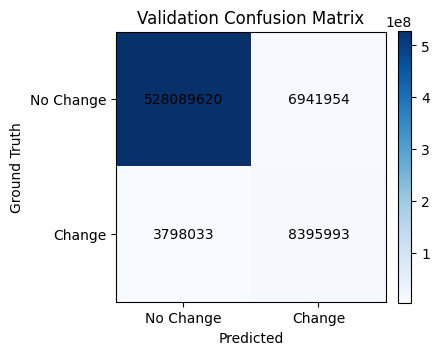

TP: 8395993 | FP: 6941954 | FN: 3798033 | TN: 528089620


In [40]:
# Confusion matrix on validation set
cm_threshold = threshold

model = model.to(device)
model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():
    for pre, post, target, _ in val_loader:
        pre = pre.to(device)
        post = post.to(device)
        target = target.to(device)

        logits = model(pre, post)
        pred = (torch.sigmoid(logits) > cm_threshold)
        target_mask = target.unsqueeze(1) if target.dim() == 3 else target
        target_mask = target_mask.bool()

        total_tp += (pred & target_mask).sum().item()
        total_fp += (pred & ~target_mask).sum().item()
        total_fn += (~pred & target_mask).sum().item()
        total_tn += (~pred & ~target_mask).sum().item()

cm = np.array([[total_tn, total_fp], [total_fn, total_tp]], dtype=np.int64)

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Validation Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground Truth")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Change", "Change"])
ax.set_yticklabels(["No Change", "Change"])

# Annotate cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn} | TN: {total_tn}")

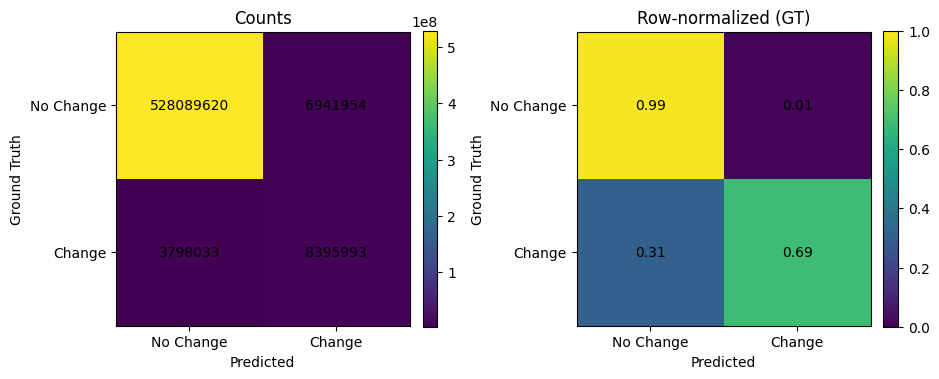

TP: 8395993 | FP: 6941954 | FN: 3798033 | TN: 528089620
Row-normalized (GT):
 [[0.98702515 0.01297485]
 [0.3114667  0.6885333 ]]


In [42]:
# Confusion matrix on validation set (counts + normalized)
cm_threshold = threshold

model = model.to(device)
model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():
    for pre, post, target, _ in val_loader:
        pre = pre.to(device)
        post = post.to(device)
        target = target.to(device)

        logits = model(pre, post)
        pred = (torch.sigmoid(logits) > cm_threshold)
        target_mask = target.unsqueeze(1) if target.dim() == 3 else target
        target_mask = target_mask.bool()

        total_tp += (pred & target_mask).sum().item()
        total_fp += (pred & ~target_mask).sum().item()
        total_fn += (~pred & target_mask).sum().item()
        total_tn += (~pred & ~target_mask).sum().item()

cm = np.array([[total_tn, total_fp], [total_fn, total_tp]], dtype=np.int64)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / np.maximum(row_sums, 1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))

# Counts
im0 = axes[0].imshow(cm, cmap="viridis")
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Ground Truth")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["No Change", "Change"])
axes[0].set_yticklabels(["No Change", "Change"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Row-normalized by ground truth
im1 = axes[1].imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Row-normalized (GT)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Ground Truth")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["No Change", "Change"])
axes[1].set_yticklabels(["No Change", "Change"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn} | TN: {total_tn}")
print("Row-normalized (GT):\n", cm_norm)

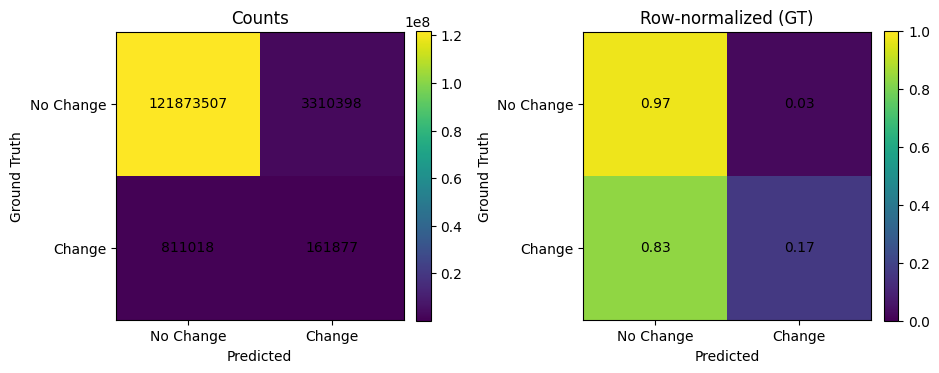

TP: 161877 | FP: 3310398 | FN: 811018 | TN: 121873507
Row-normalized (GT):
 [[0.97355572 0.02644428]
 [0.83361308 0.16638692]]


In [9]:
# Confusion matrix on validation set (counts + normalized)
cm_threshold = threshold

model = model.to(device)
model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():
    for pre, post, target, _ in test_loader:
        pre = pre.to(device)
        post = post.to(device)
        if target.max().item() > 1:
            target = torch.from_numpy(remap_labels(target.cpu().numpy())).to(dtype=target.dtype)
        target = target.to(device)

        logits = model(pre, post)
        pred = (torch.sigmoid(logits) > cm_threshold)
        target_mask = target.unsqueeze(1) if target.dim() == 3 else target
        target_mask = target_mask.bool()

        total_tp += (pred & target_mask).sum().item()
        total_fp += (pred & ~target_mask).sum().item()
        total_fn += (~pred & target_mask).sum().item()
        total_tn += (~pred & ~target_mask).sum().item()

cm = np.array([[total_tn, total_fp], [total_fn, total_tp]], dtype=np.int64)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / np.maximum(row_sums, 1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))

# Counts
im0 = axes[0].imshow(cm, cmap="viridis")
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Ground Truth")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["No Change", "Change"])
axes[0].set_yticklabels(["No Change", "Change"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Row-normalized by ground truth
im1 = axes[1].imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Row-normalized (GT)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Ground Truth")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["No Change", "Change"])
axes[1].set_yticklabels(["No Change", "Change"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"TP: {total_tp} | FP: {total_fp} | FN: {total_fn} | TN: {total_tn}")
print("Row-normalized (GT):\n", cm_norm)